# Tension Board 2 / Tension Board 1: Data Overview and Climbing Statistics

## Purpose

This notebook establishes the basic statistical landscape of the dataset before we move into hold-level analysis and predictive modelling. The main goals are:

1. to understand the size and scope of the data,
2. to compare layouts, boards, and angles at a high level,
3. to identify broad trends in grade, popularity, and quality,
4. to create a clean descriptive baseline for the later modelling notebooks.

Throughout, I treat each climb-angle entry as a separate observation unless explicitly noted otherwise. That matters because some climbs appear at multiple angles, so a unique climb count and a climb-angle count are not always the same thing.

## Outputs

This notebook produces summary tables and exploratory plots that motivate the later notebooks on:
- hold usage,
- hold difficulty,
- feature engineering,
- predictive modelling,
- and deep learning.

## Notebook Structure
1. [Setup and Imports](#setup-and-imports)
2. [Popularity and Temporal Trends](#popularity-and-temporal-trends)
3. [Climbing Statistics](#climbing-statistics-grades-angles-quality-and-matching)
4. [Prolific Statistics](#prolific-statistics)
5. [Conclusion](#conclusion)

## Setup and Imports

In [1]:
"""
==================================
Setup and imports
==================================
"""
# Imports
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import matplotlib.patches as mpatches
import sqlite3


# Set some display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set style
palette=['steelblue', 'coral', 'seagreen']  #(for multi-bar graphs)

# Connect to the database
DB_PATH="../data/tb2.db"
conn = sqlite3.connect(DB_PATH)


In [2]:
"""
==================================
### Query our data from the DB
==================================
"""

# Query climb data
climbs_query = """
SELECT
    c.uuid,
    c.name AS climb_name,
    c.setter_username,
    c.layout_id AS layout_id,
    c.description,
    c.is_nomatch,
    c.is_listed,
    l.name AS layout_name,
    p.name AS board_name,
    c.frames,
    cs.angle,
    cs.display_difficulty,
    dg.boulder_name AS boulder_grade,
    cs.ascensionist_count,
    cs.quality_average,
    cs.fa_at
    
FROM climbs c
JOIN layouts l ON c.layout_id = l.id
JOIN products p ON l.product_id = p.id
JOIN climb_stats cs ON c.uuid = cs.climb_uuid
JOIN difficulty_grades dg ON ROUND(cs.display_difficulty) = dg.difficulty
WHERE cs.display_difficulty IS NOT NULL;
"""

# Load it into a DataFrame
df = pd.read_sql_query(climbs_query, conn)

The above query will allow us to gather basically anything we need to in order to analyze climbing statistics. We leave out information about climging holds and things like this, because they will be analyzed in a different notebook. Let's see what our DataFrame looks like.

In [3]:
df

,uuid,climb_name,setter_username,layout_id,description,is_nomatch,is_listed,layout_name,board_name,frames,angle,display_difficulty,boulder_grade,ascensionist_count,quality_average,fa_at
0,0004edf6aeac9618d96a3b949cd9a724,Jumping Giraffe,david.p.kunz,9,,0,1,Original Layout,Tension Board,p42r1p71r4p76r1p89r2p91r3p104r2p111r2p232r2,40,24.0000,7b/V8,2,3.00000,2020-03-23 23:52:37
1,00072fbd8c22711ef3532a5017c1a5c2,Albatross,free.and.independent,9,No Matching,1,1,Original Layout,Tension Board,p31r2p49r2p52r2p53r2p87r3p92r1p99r2p118r2p120r...,25,19.2500,6b+/V4,4,3.00000,2019-10-05 01:55:14
2,0008d8af4649234054bea434aaeabaab,crossup,judemandudeman,9,,0,1,Original Layout,Tension Board,p22r2p58r2p76r1p83r3p166r2p228r2p280r4,45,20.0000,6c/V5,2,2.00000,2018-01-30 03:18:13
3,000eb831d3a1e92ea8fdec2518fd77d3,For the love of Tension,willrossiter,9,No matching,1,1,Original Layout,Tension Board,p86r3p95r1p131r2p151r2p171r1p173r2p187r2p261r4...,20,18.0000,6b/V4,1,3.00000,2019-03-15 15:46:06
4,000eb831d3a1e92ea8fdec2518fd77d3,For the love of Tension,willrossiter,9,No matching,1,1,Original Layout,Tension Board,p86r3p95r1p131r2p151r2p171r1p173r2p187r2p261r4...,40,23.0000,7a+/V7,1,3.00000,2021-06-27 22:41:10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147041,0B714869B80248D1B698E449EE885AB0,Loch Ness Monster,bennykuttler1285,10,No matching,1,1,Tension Board 2 Mirror,Tension Board 2,p333r6p344r6p367r8p379r8p380r5p500r8p570r6p579...,45,16.0000,6a/V3,3468,2.98991,2022-12-28 17:42:57
147042,71C4F8D564D045EFA1C9F26BB949E040,$2 lap dance 💃🕺,nelldell,10,No Match,1,1,Tension Board 2 Mirror,Tension Board 2,p311r6p320r5p366r8p372r7p445r5p462r6p468r8p570r6,40,20.0000,6c/V5,3388,2.98022,2022-12-07 00:30:56
147043,B998C0712A2240E8AC858CB72E9115D5,Aftermath,tensionclimbing,10,,0,1,Tension Board 2 Mirror,Tension Board 2,p350r8p370r8p464r6p569r5p589r7p685r5p718r6p767r8,40,23.0000,7a+/V7,3,3.00000,2023-07-04 20:16:10
147044,C67E01D16E2940C2AFA76B436F9541D5,curly fries,sidpintobean,10,no matching,1,1,Tension Board 2 Mirror,Tension Board 2,p485r8p497r8p692r6p716r6p722r6p726r6p740r6p753...,40,20.1111,6c/V5,18,2.88889,2024-03-22 19:39:34


---

# Popularity and Temporal Trends

## Popularity of Tension Board

Since we do not have access to user data, we will examine the popular of the Tension Boards by counting first ascents and unique setters by year. Often it's the case that the first ascensionist is the also the setter of the climb, but not always. None the less, we group up first ascensionists by year, with an extra tidbit about how many unique setters there were. 

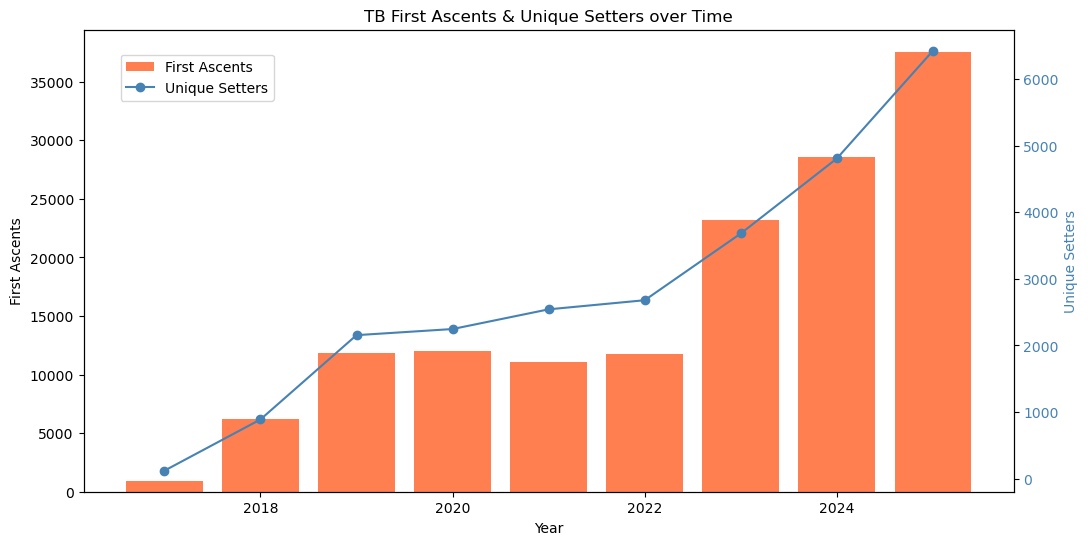

In [4]:
"""
==================================
Popular of tension board by year. 
First ascents by year + unique setters by year
==================================
"""

# Convert df['fa_at'] to datetime format. (For some reason, it does not register as such)
df['fa_at'] = pd.to_datetime(df['fa_at'])

# Add a new column for the year
df['fa_year'] = df['fa_at'].dt.year

# Make a new DataFrame with year, first_ascents, and unique_setters
df_growth = df.groupby('fa_year').agg(
    first_ascents=('uuid', 'count'),
    unique_setters=('setter_username', 'nunique')
).reset_index()

# Disregard the year 2026 since the data only goes one month in. 
df_growth = df_growth[df_growth['fa_year'] < 2026]

## Plot
# Dual index plotting

fig, ax1 = plt.subplots(figsize=(12,6))

# Bar chart for first ascents
ax1.bar(df_growth['fa_year'], df_growth['first_ascents'], label='First Ascents', color='coral')
ax1.set_xlabel('Year')
ax1.set_ylabel('First Ascents')
ax1.set_title('TB First Ascents & Unique Setters over Time')
#ax1.tick_params(axis='y')

# Line chart for unique setters (secondary axis)
ax2 = ax1.twinx()
ax2.plot(df_growth['fa_year'], df_growth['unique_setters'], color='steelblue', marker='o', label='Unique Setters')
ax2.set_ylabel('Unique Setters', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

# Other stuff
fig.legend(loc='upper left', bbox_to_anchor=(0.15,0.85))

plt.xticks()
plt.savefig('../images/01_climb_stats/first_ascents_by_year.png')
plt.show()

## Seasonal analysis

Next, we examine when the Tension board is most popular. Again, we will work with what we have and use first ascent data. We will plot first ascents by month, combing all years. We exclude the year 2026 because this can skew the analysis as some of the month of January has data (and clearly, 2026 is when the TB2 is the most popular, so this can actually add quite a bit bias). 

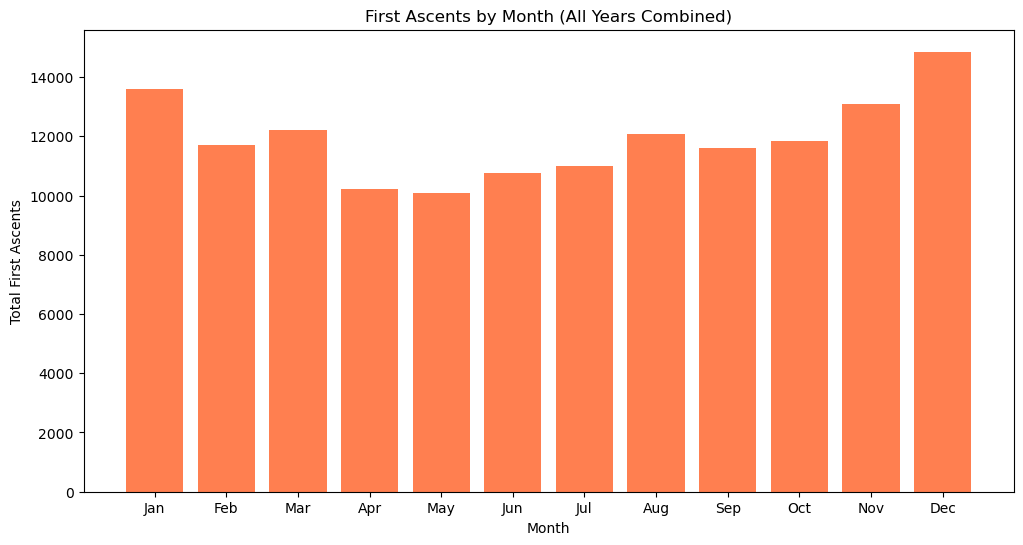

In [5]:
"""
==================================
Season analysis: first ascents by month
==================================
"""

# First let us add a column for the month to our data
df['fa_month'] = df['fa_at'].dt.month

# Filter to years < 2026 since the data only goes one month in
df_filter = df[df['fa_year'] < 2026]

# Make a new DataFrame with month and first ascents
df_season = df_filter.groupby('fa_month').agg(
    first_ascents=('uuid', 'count'),
).reset_index()

# We also add a column for the month name. 
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_season['fa_month_name'] = df_season['fa_month'].apply(lambda x: month_names[x-1])

# Plot the data
fig,ax = plt.subplots(figsize=(12,6))
ax.bar(df_season['fa_month_name'], df_season['first_ascents'], color='coral')
ax.set_title('First Ascents by Month (All Years Combined)')
ax.set_xlabel('Month')
ax.set_ylabel('Total First Ascents')

# Save the file
plt.savefig('../images/01_climb_stats/first_ascents_by_month.png')
plt.show()

This should be what we expect: that the winter months (Dec/Jan) see the most traffic. This is probably when the outdoor climbers are hitting the boards because they're stuck inside. The warmer months see the least number of first ascents since the strong climbers are probably outdoors.

## Day of Week Analysis

We can plot the number of first ascents by day of week. Removing the 2026 data shouldn't make a difference here, so we opt to keep it.

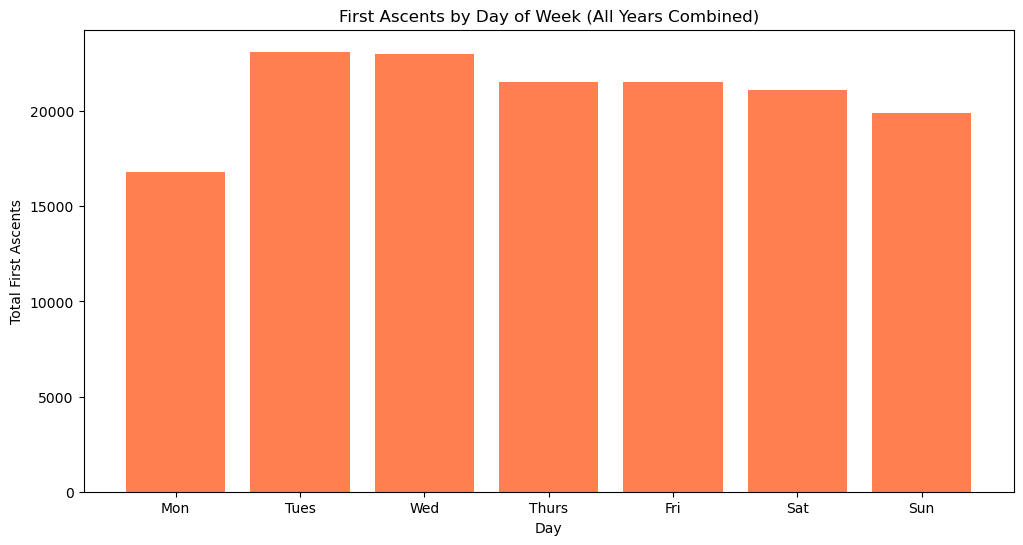

In [6]:
"""
==================================
Day of Week analysis
==================================
"""

# Let us add a column in our DataFrame for the day of the week.
# Note that df.dt.day_of_week will have Monday be 0 and Sunday be 6. 

df['fa_day_of_week'] = df['fa_at'].dt.day_of_week


# Make a new DataFrame with month and first ascents
df_days = df.groupby('fa_day_of_week').agg(
    first_ascents=('uuid', 'count'),
).reset_index()

# We also add a column for the month name. 
day_names = ['Mon', 'Tues', 'Wed', 'Thurs', 'Fri', 'Sat', 'Sun']
df_days['fa_day_name'] = df_days['fa_day_of_week'].apply(lambda x: day_names[x])

# Plot the data
fig,ax = plt.subplots(figsize=(12,6))
ax.bar(df_days['fa_day_name'], df_days['first_ascents'], color='coral')
ax.set_title('First Ascents by Day of Week (All Years Combined)')
ax.set_xlabel('Day')
ax.set_ylabel('Total First Ascents')

# Save the file
plt.savefig('../images/01_climb_stats/first_ascents_by_day_of_week.png')
plt.show()



Interesting, Tuesday and Wednesday have the most traffic, while Monday is the least popular.

## Time of Day Analysis

We can even do a time of day analysis. Again, we will keep the 2026 data since it shouldn't affect much. It is not entirely clear that makes sense to look at this, as we don't know if the time of first ascent is recorded in local time of the climber or local time of the server. These boards are all over the world, so this may add quite a bit of variance.

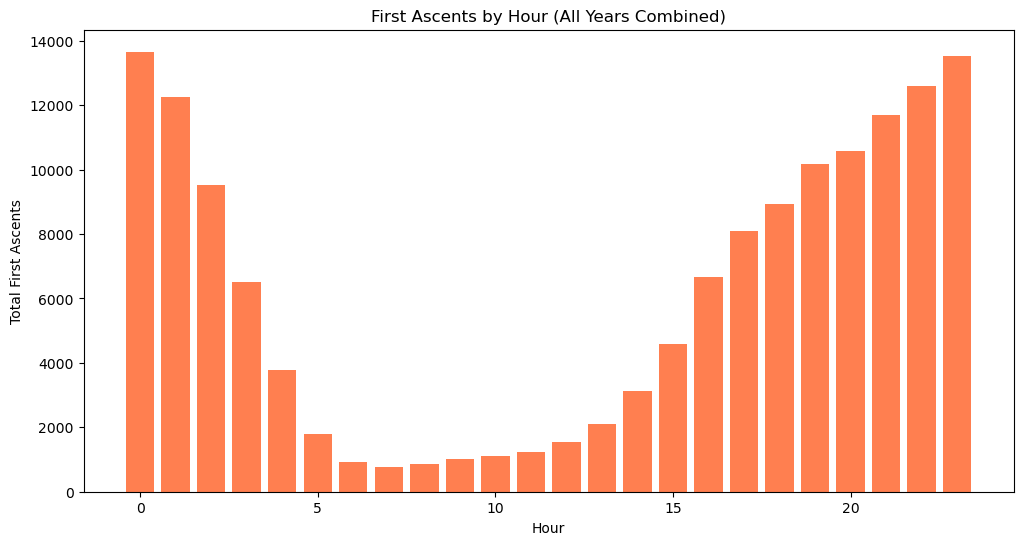

In [7]:
"""
==================================
Time of Day analysis
==================================
"""

# Let us add a column in our DataFrame for the day of the week.
# Note that df.dt.day_of_week will have Monday be 0 and Sunday be 6. 

df['fa_hour'] = df['fa_at'].dt.hour


# Make a new DataFrame with month and first ascents
df_hour = df.groupby('fa_hour').agg(
    first_ascents=('uuid', 'count'),
).reset_index()

# We also add a column for the month name. 
#df_time['fa_day_name'] = df_time['fa_day_of_week'].apply(lambda x: day_names[x])

# Plot the data
fig,ax = plt.subplots(figsize=(12,6))
ax.bar(df_hour['fa_hour'], df_hour['first_ascents'], color='coral')
ax.set_title('First Ascents by Hour (All Years Combined)')
ax.set_xlabel('Hour')
ax.set_ylabel('Total First Ascents')

# Save the file
plt.savefig('../images/01_climb_stats/first_ascents_by_hour.png')
plt.show()



---

# Climbing Statistics: Grades, Angles, Quality, and Matching

We will visualize the climbing grade distribution. Recall that we have the following table of grades (with some other unlisted grades).

|difficulty|boulder_name|route_name|
|----------|------------|----------|
|        10|4a/V0       |5b/5.9    |
|        11|4b/V0       |5c/5.10a  |
|        12|4c/V0       |6a/5.10b  |
|        13|5a/V1       |6a+/5.10c |
|        14|5b/V1       |6b/5.10d  |
|        15|5c/V2       |6b+/5.11a |
|        16|6a/V3       |6c/5.11b  |
|        17|6a+/V3      |6c+/5.11c |
|        18|6b/V4       |7a/5.11d  |
|        19|6b+/V4      |7a+/5.12a |
|        20|6c/V5       |7b/5.12b  |
|        21|6c+/V5      |7b+/5.12c |
|        22|7a/V6       |7c/5.12d  |
|        23|7a+/V7      |7c+/5.13a |
|        24|7b/V8       |8a/5.13b  |
|        25|7b+/V8      |8a+/5.13c |
|        26|7c/V9       |8b/5.13d  |
|        27|7c+/V10     |8b+/5.14a |
|        28|8a/V11      |8c/5.14b  |
|        29|8a+/V12     |8c+/5.14c |
|        30|8b/V13      |9a/5.14d  |
|        31|8b+/V14     |9a+/5.15a |
|        32|8c/V15      |9b/5.15b  |
|        33|8c+/V16     |9b+/5.15c |

We will use the actual difficulty in our work, and then unpack translations into boulder_name as we see fit.

## Grade distribution

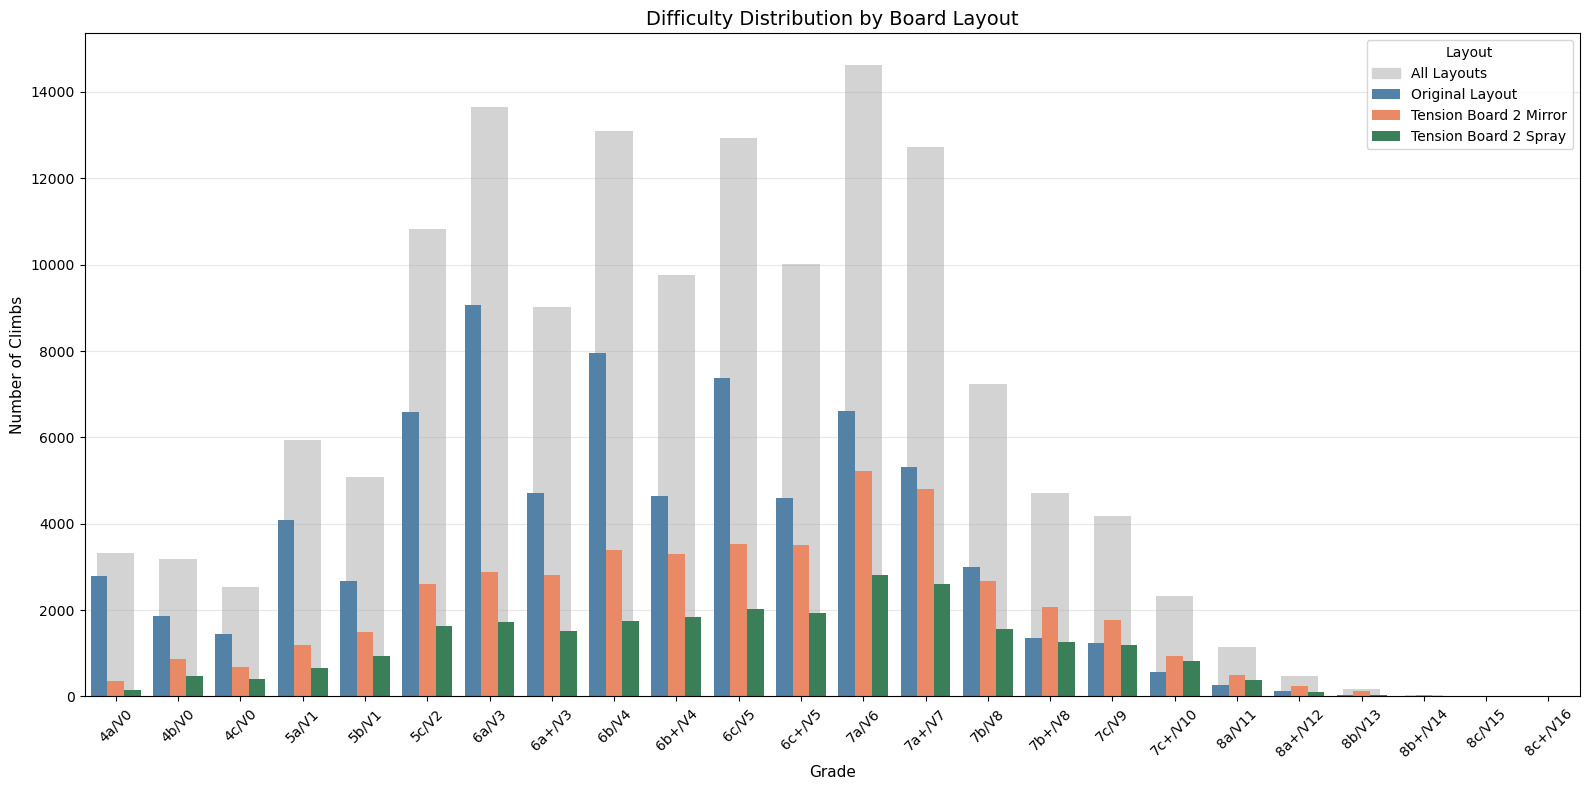

In [8]:
"""
==================================
Difficulty distribution by layout (with total)
==================================
"""

grade_counts = df['boulder_grade'].value_counts()
grade_order = df.groupby('boulder_grade')['display_difficulty'].mean().sort_values().index.tolist()
grade_counts = grade_counts.reindex(grade_order)

# Prepare data in long format
df_long = df.groupby(['boulder_grade', 'layout_name']).size().reset_index(name='count')

# Calculate total for background
df_total = df.groupby('boulder_grade').size().reset_index(name='count')
df_total['layout_name'] = 'All Layouts'

# Reindex to correct grade order
df_long['grade_order'] = df_long['boulder_grade'].map(
    {g: i for i, g in enumerate(grade_order)}
)
df_long = df_long.sort_values('grade_order')

df_total['grade_order'] = df_total['boulder_grade'].map(
    {g: i for i, g in enumerate(grade_order)}
)
df_total = df_total.sort_values('grade_order')

# Plot
fig, ax = plt.subplots(figsize=(16, 8))

# Plot "All Layouts" behind (light gray)
sns.barplot(
    data=df_total,
    x='boulder_grade',
    y='count',
    color='lightgray',
    ax=ax,
    zorder=1,
    width=0.6,
    order=grade_order
)

# Plot individual layouts (grouped) in front
sns.barplot(
    data=df_long,
    x='boulder_grade',
    y='count',
    hue='layout_name',
    palette=['steelblue', 'coral', 'seagreen'],
    ax=ax,
    zorder=2,
    order=grade_order
)

# Create custom legend with "All Layouts" included
handles, labels = ax.get_legend_handles_labels()
all_layouts_patch = mpatches.Patch(color='lightgray', label='All Layouts')
handles.insert(0, all_layouts_patch)
ax.legend(handles=handles, title='Layout', fontsize=10)

ax.set_xlabel('Grade', fontsize=11)
ax.set_ylabel('Number of Climbs', fontsize=11)
ax.set_title('Difficulty Distribution by Board Layout', fontsize=14)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/01_climb_stats/difficulty_distribution_by_layout_with_total.png', dpi=150, bbox_inches='tight')
plt.show()

As a climber in North America, I tend to just use the V-grade and not look at the French grade. So let us group the V-grades together and show the distribution like that. We'll usually just stick the boulder_grade (e.g., 5c/V2) instead of grouping the V-grades though. 

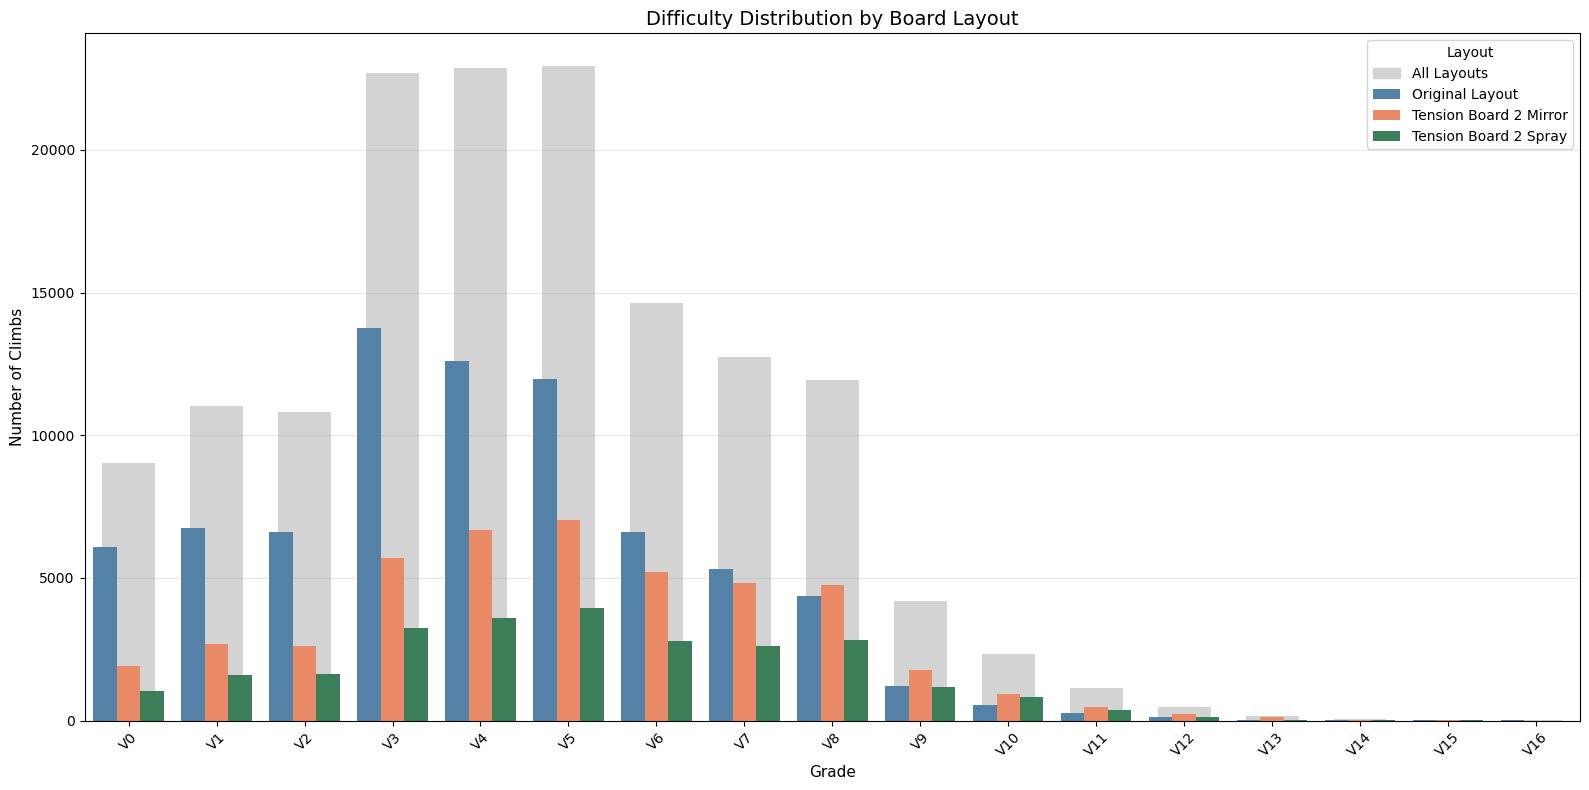

In [9]:
"""
==================================
V-Grade distribution by layout (with total)
==================================
"""

# Let's add a v_grade column and v_grade_counts
df['v_grade'] = df['boulder_grade'].str.split('/').str[1]
v_grade_counts = df['v_grade'].value_counts()
v_grade_order = df.groupby('v_grade')['display_difficulty'].mean().sort_values().index.tolist()
v_grade_counts = grade_counts.reindex(v_grade_order)

# Prepare data in long format
df_long = df.groupby(['v_grade', 'layout_name']).size().reset_index(name='count')

# Calculate total for background
df_total = df.groupby('v_grade').size().reset_index(name='count')
df_total['layout_name'] = 'All Layouts'

# Reindex to correct grade order
df_long['v_grade_order'] = df_long['v_grade'].map(
    {g: i for i, g in enumerate(v_grade_order)}
)
df_long = df_long.sort_values('v_grade_order')

df_total['v_grade_order'] = df_total['v_grade'].map(
    {g: i for i, g in enumerate(v_grade_order)}
)
df_total = df_total.sort_values('v_grade_order')

# Plot
fig, ax = plt.subplots(figsize=(16, 8))

# Plot "All Layouts" behind (light gray)
sns.barplot(
    data=df_total,
    x='v_grade',
    y='count',
    color='lightgray',
    ax=ax,
    zorder=1,
    width=0.6,
    order=v_grade_order
)

# Plot individual layouts (grouped) in front
sns.barplot(
    data=df_long,
    x='v_grade',
    y='count',
    hue='layout_name',
    palette=palette,
    ax=ax,
    zorder=2,
    order=v_grade_order
)

# Create legend with "All Layouts" included
handles, labels = ax.get_legend_handles_labels()
all_layouts_patch = mpatches.Patch(color='lightgray', label='All Layouts')
handles.insert(0, all_layouts_patch)
ax.legend(handles=handles, title='Layout', fontsize=10)

ax.set_xlabel('Grade', fontsize=11)
ax.set_ylabel('Number of Climbs', fontsize=11)
ax.set_title('Difficulty Distribution by Board Layout', fontsize=14)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/01_climb_stats/v_grade_distribution_by_layout_with_total.png', dpi=150, bbox_inches='tight')
plt.show()

So the grade distribution actually varies quite a bit from board to board. Some key differences in grades are the angle at which the climb is. Note that climbs can be done at different angles.

## Angle Distribution

What about the angle distribution? Since the TB1 goes from 0 to 50 and the TB2 goes from 0 to 65 (although my local board only goes to 60?), let's do an analysis on each.

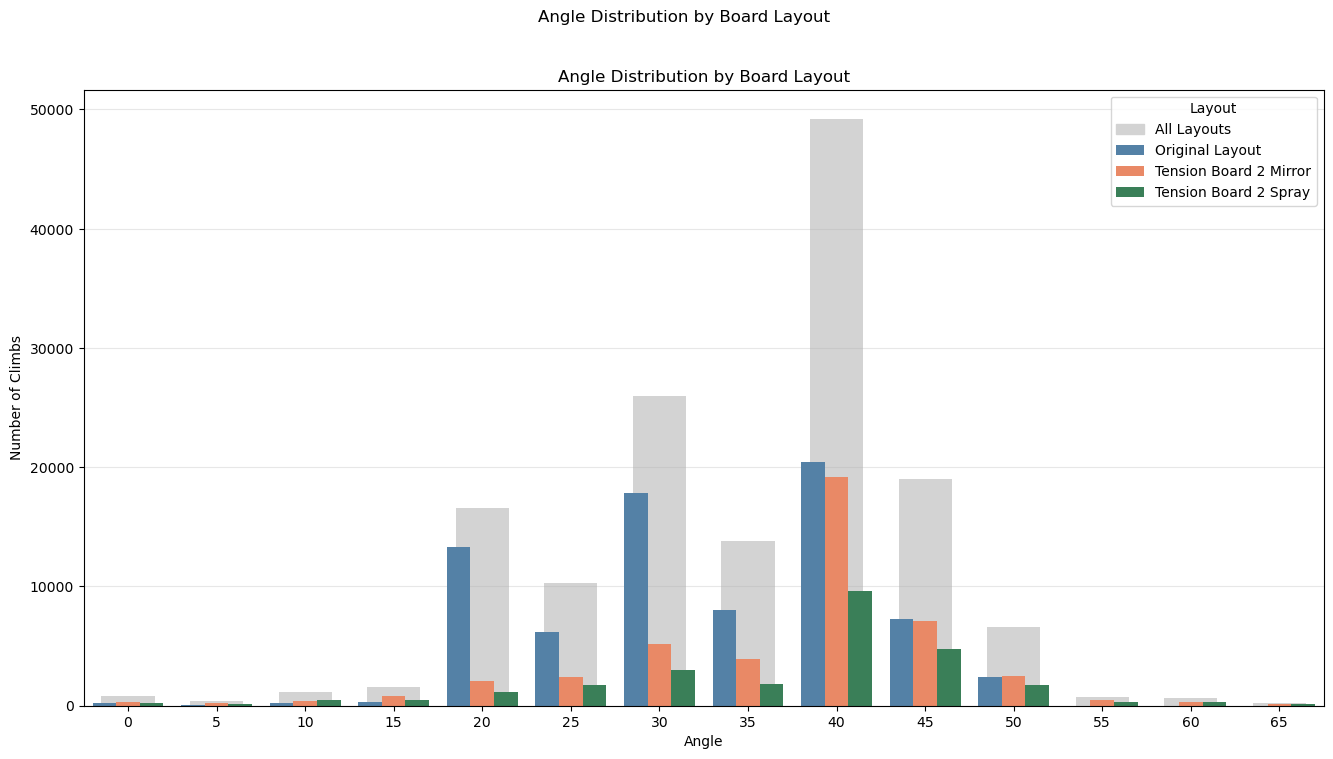

In [10]:
"""
==================================
Angle distribution
==================================
"""

# TB1 goes up to 50 degrees, TB2 up to 65. (Although my local TB2 only goes up to 60 -- brutal climbing)

# Prepare data in long format
df_long = df.groupby(['angle', 'layout_name']).size().reset_index(name='count')

# Calculate total for background
df_total = df.groupby('angle').size().reset_index(name='count')
df_total['layout_name'] = 'All Layouts'

# Reindex to correct order
angle_order = sorted(df['angle'].unique())

# Plot
fix, ax = plt.subplots(figsize=(16,8))

# Plot All Layouts
sns.barplot(
    data=df_total,
    x='angle',
    y='count',
    color='lightgray',
    ax=ax,
    zorder=1,
    width=0.6,
    order=angle_order
)

# Plt indivudual layouts
sns.barplot(
    data=df_long,
    x='angle',
    y='count',
    hue='layout_name',
    palette=palette,
    order=angle_order,
    ax=ax,
    zorder=2
)

handles,labels = ax.get_legend_handles_labels()
all_layouts_patch = mpatches.Patch(color='lightgray', label='All Layouts')
handles.insert(0, all_layouts_patch)
ax.legend(handles=handles, title='Layout')

ax.set_xlabel('Angle')
ax.set_ylabel('Number of Climbs')
ax.set_title('Angle Distribution by Board Layout')
ax.grid(axis='y', alpha=0.3)


plt.suptitle('Angle Distribution by Board Layout')
plt.savefig('../images/01_climb_stats/angle_distribution_by_layout.png')
plt.show()

We see that for all the boards, 40 degrees is the most common angle.

## Angle vs grade

How is the distribution between angles and grades? Let's do this with a heatmap.

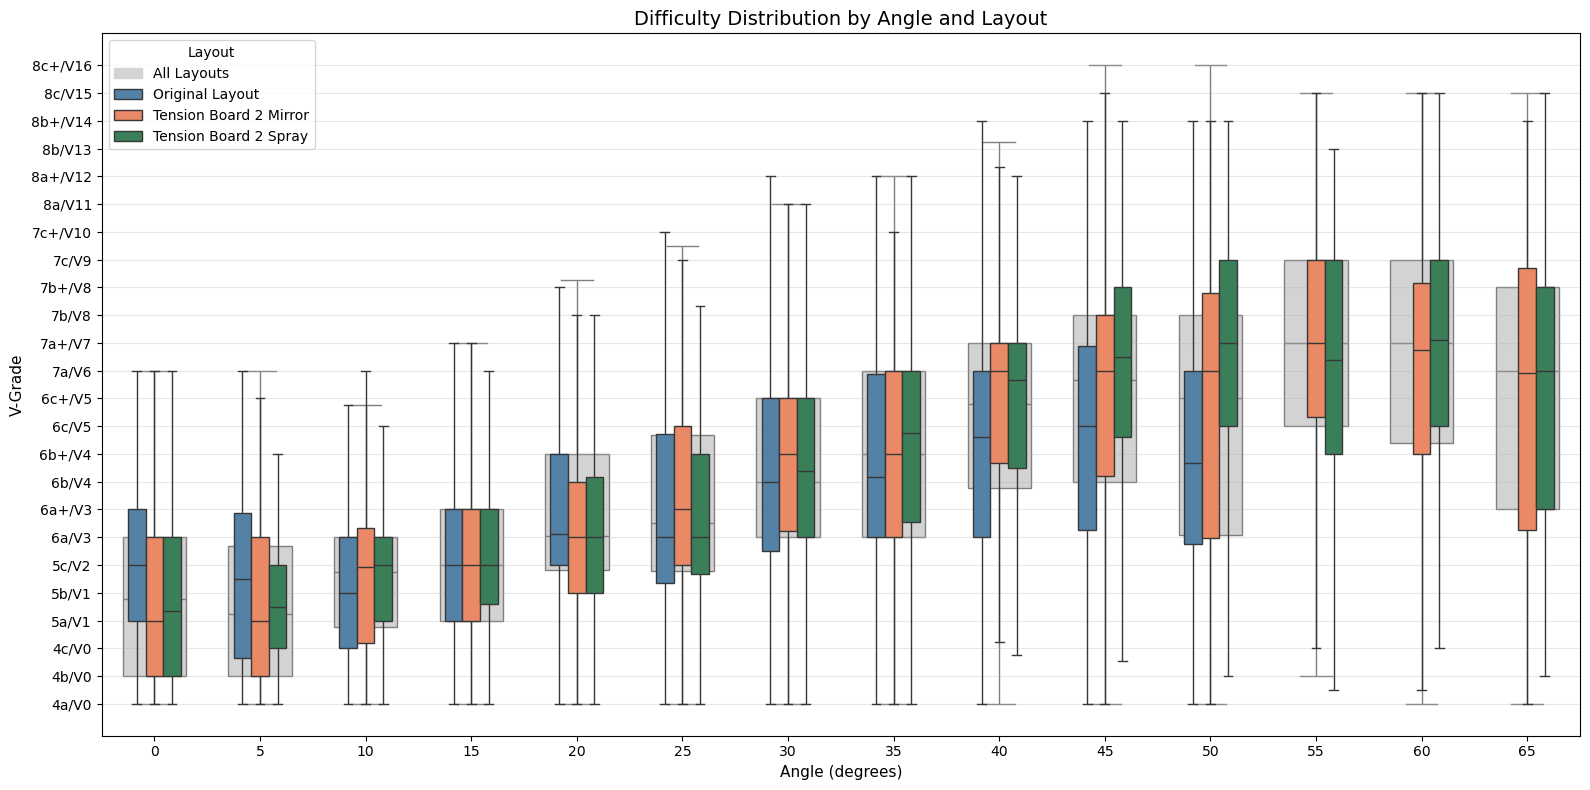

In [11]:
"""
==================================
Angle vs grade
==================================
"""

fig, ax = plt.subplots(figsize=(16, 8))

# Create mapping from difficulty to V-grade
grade_mapping = df.groupby('display_difficulty')['boulder_grade'].first().to_dict()

# Plot "All Layouts" as faint background boxes
sns.boxplot(
    data=df,
    x='angle',
    y='display_difficulty',
    color='lightgray',
    order=angle_order,
    showfliers=False,
    width=0.6,
    ax=ax,
    zorder=1
)

# Plot individual layouts in front
sns.boxplot(
    data=df,
    x='angle',
    y='display_difficulty',
    hue='layout_name',
    hue_order=['Original Layout', 'Tension Board 2 Mirror', 'Tension Board 2 Spray'], # For some reason this plot goes TB2 Spray / TB1 Orig / TB2 Mirror. Simple fix.
    palette=['steelblue', 'coral', 'seagreen'],
    order=angle_order,
    showfliers=False,
    ax=ax,
    width=0.5,
    zorder=2
)

# Relabel y-axis with boulder_grades
yticks_rounded = sorted(set(int(round(t)) for t in df['display_difficulty'].unique() if not pd.isna(t)))
ylabels = [grade_mapping.get(t, '') for t in yticks_rounded]
ax.set_yticks(yticks_rounded)
ax.set_yticklabels(ylabels)

# Custom legend with "All Layouts"
handles, labels = ax.get_legend_handles_labels()
all_patch = mpatches.Patch(color='lightgray', label='All Layouts')
handles.insert(0, all_patch)
ax.legend(handles=handles, title='Layout', fontsize=10)

ax.set_xlabel('Angle (degrees)', fontsize=11)
ax.set_ylabel('V-Grade', fontsize=11)
ax.set_title('Difficulty Distribution by Angle and Layout', fontsize=14)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/01_climb_stats/difficulty_by_angle_boxplot_by_layout.png', dpi=150, bbox_inches='tight')
plt.show()

## The Quality of a climb

Next we examine the quality of a climb. First we look at how quality relates to the number of ascents.

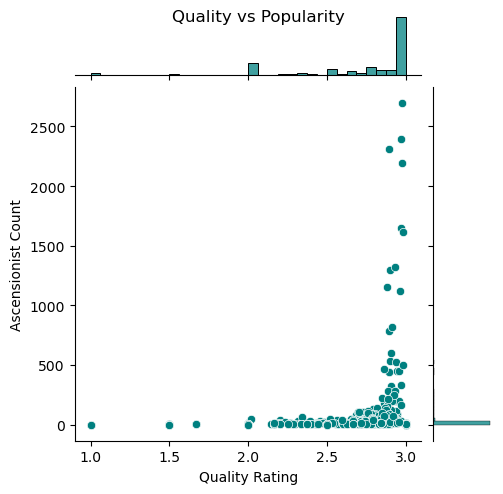

In [12]:
"""
==================================
Climb quality vs popularity
==================================
"""

# Filter to climbs with quality ratings
df_quality = df[(df['quality_average'].notna()) & (df['quality_average'] > 0)]

# Sample for performance
df_sample = df_quality.sample(min(2000, len(df_quality)))

g = sns.jointplot(
    data=df_sample,
    x='quality_average',
    y='ascensionist_count',
    kind='scatter',
    color='teal',
    height=5
)

g.ax_joint.set_xlabel('Quality Rating')
g.ax_joint.set_ylabel('Ascensionist Count')
g.fig.suptitle('Quality vs Popularity')

plt.savefig('../images/01_climb_stats/quality_popularity.png', dpi=150, bbox_inches='tight')
plt.show()

Next we visualize the average quality vs the angle and grade, by means of a heatmap. Keep in mind that the harder the climb and steeper the angle, the less people will be doing it. So harder climbs are skewed towards people who can actually do it. The point is that, on boards, the climb quality isn't always the best metric. As such, we won't spend too much time on the quality and will only do a heatmap which takes into account all layouts.

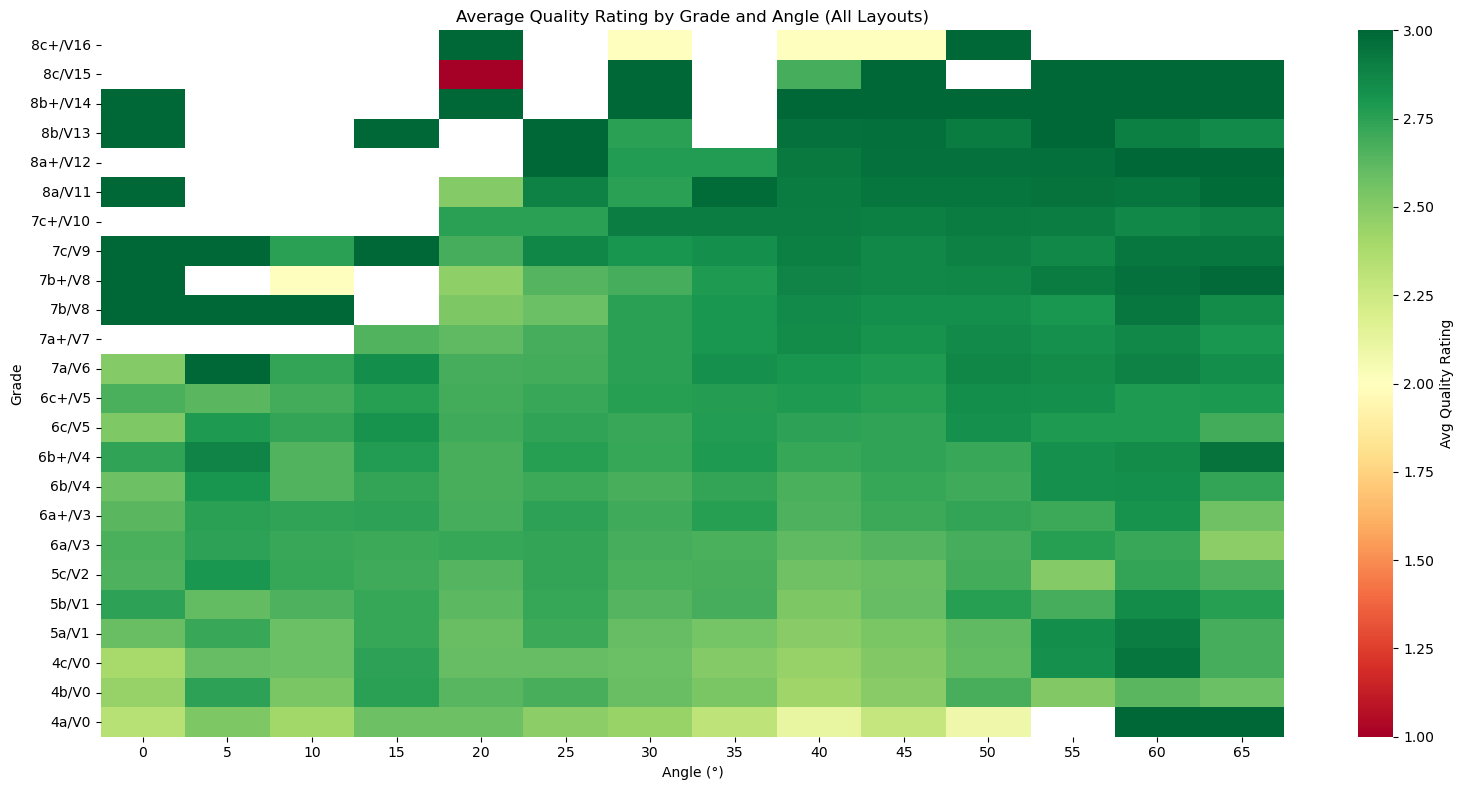

In [13]:
### Average quality by angle and grade

# Filter to climbs with quality ratings
df_quality = df[(df['quality_average'].notna()) & (df['quality_average'] > 0)]


# Create pivot table
quality_pivot = df_quality.pivot_table(
    index='boulder_grade',
    columns='angle',
    values='quality_average',
    aggfunc='mean'
)
quality_pivot = quality_pivot.reindex(grade_order)
quality_pivot = quality_pivot.reindex(columns=[a for a in angle_order if a in quality_pivot.columns])

# Plot
fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(
    quality_pivot,
    cmap='RdYlGn',
    cbar_kws={'label': 'Avg Quality Rating'},
    ax=ax
)

ax.set_xlabel('Angle (°)')
ax.set_ylabel('Grade')
ax.invert_yaxis()
ax.set_title('Average Quality Rating by Grade and Angle (All Layouts)')

plt.tight_layout()
plt.savefig('../images/01_climb_stats/quality_heatmap_all_layouts.png', dpi=150, bbox_inches='tight')
plt.show()

## "Match" vs. "No Match"

Some setters opt to put the "no match" tag onto their climbs. This means that the climber is not allowed to match their hands on any hold. Let's do an analysis of the differences with regular climbs.

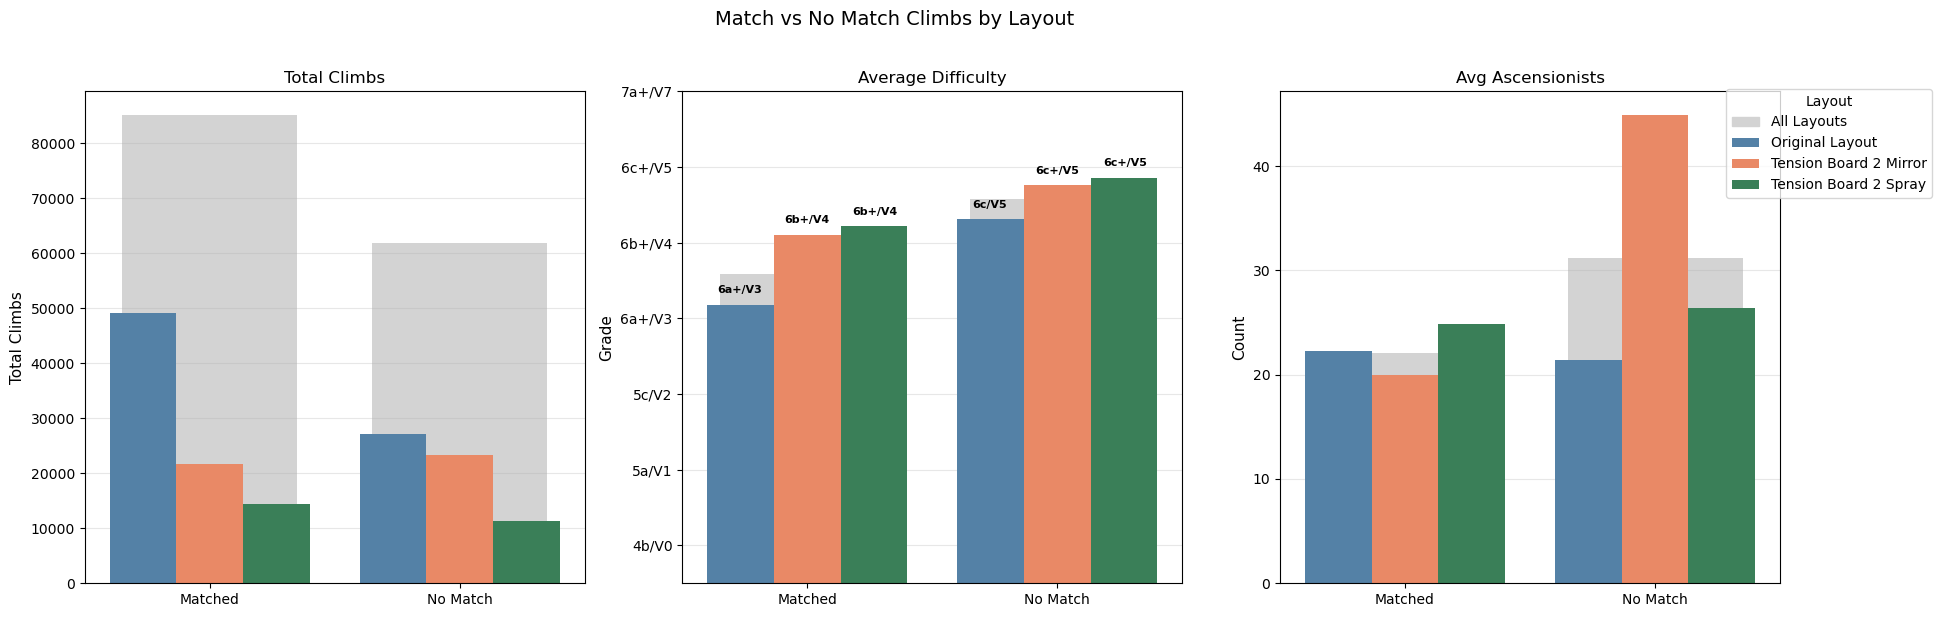

In [14]:
"""
==================================
Match vs No Match analysis
==================================
"""

# Create status column (Match vs No Match)
df['status'] = df.apply(
    lambda x: 'No Match' if (
        pd.notna(x['description']) and 'No matching' in str(x['description'])
    ) or x.get('is_nomatch', 0) == 1 else 'Matched',
    axis=1
)

# Aggregate by layout and status
df_agg = df.groupby(['layout_name', 'status']).agg(
    count=('uuid', 'count'),
    avg_ascensionists=('ascensionist_count', 'mean'),
    avg_difficulty=('display_difficulty', 'mean')
).reset_index()

# Calculate All Layouts totals
df_all = df.groupby('status').agg(
    count=('uuid', 'count'),
    avg_ascensionists=('ascensionist_count', 'mean'),
    avg_difficulty=('display_difficulty', 'mean')
).reset_index()
df_all['layout_name'] = 'All Layouts'

# Combine
df_combined = pd.concat([df_agg, df_all], ignore_index=True)

# Order
status_order = ['Matched', 'No Match']


# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, metric, title in zip(axes, ['count', 'avg_difficulty', 'avg_ascensionists'], 
                               ['Total Climbs', 'Average Difficulty', 'Avg Ascensionists']):
    
    # All Layouts as background (separate for each status)
    for i, status in enumerate(status_order):
        df_bg = df_combined[(df_combined['layout_name'] == 'All Layouts') & 
                            (df_combined['status'] == status)]
        
        if not df_bg.empty:
            # Position for status
            x_pos = i
            ax.bar(
                x_pos,
                df_bg[metric].values[0],
                width=0.7,
                color='lightgray',
                zorder=1
            )
    
    # Individual layouts in front
    df_plot = df_combined[df_combined['layout_name'] != 'All Layouts']
    
    sns.barplot(
        data=df_plot,
        x='status',
        y=metric,
        hue='layout_name',
        palette=palette,
        order=status_order,
        ax=ax,
        zorder=2
    )
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel(title if metric == 'count' else ('Grade' if metric == 'avg_difficulty' else 'Count'), fontsize=11)
    ax.legend_.remove()
    ax.grid(axis='y', alpha=0.3)

# Y-axis labels for difficulty plot
yticks = [11, 13, 15, 17, 19, 21, 23]
ylabels = [grade_mapping.get(t, f"V{t-10}") for t in yticks]
axes[1].set_yticks(yticks)
axes[1].set_yticklabels(ylabels)
axes[1].set_ylim(bottom=10)

# Add V-grade annotations on difficulty bars
for i, status in enumerate(status_order):
    for j, layout in enumerate(df['layout_name'].unique()):
        row = df_combined[(df_combined['layout_name'] == layout) & (df_combined['status'] == status)]
        if not row.empty:
            diff = row['avg_difficulty'].values[0]
            v_grade = grade_mapping.get(round(diff), '')
            # Position: x = status index + offset for layout
            x_pos = i + (j - 1) * 0.27
            axes[1].text(x_pos, diff + 0.3, v_grade, ha='center', fontsize=8, fontweight='bold')


# Custom Legend
handles,labels = ax.get_legend_handles_labels()
all_layouts_patch = mpatches.Patch(color='lightgray', label='All Layouts')
handles.insert(0, all_layouts_patch)
fig.legend(handles=handles, title='Layout', bbox_to_anchor=(1.08, 0.9))

plt.suptitle('Match vs No Match Climbs by Layout', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../images/01_climb_stats/match_vs_nomatch_by_layout.png', dpi=150, bbox_inches='tight')
plt.show()

So we gather the following about "no match" climbs:

- they are far fewer than "match" climbs,
- they are on average harder than "match" climbs,
- and that they tend to have a bit more ascensionists on the TB2, and less on the TB1 (although, much more overall).

In [15]:
"""
==================================
Match vs No Match Summary
==================================
"""

summary = df_combined.pivot_table(
    index='layout_name',
    columns='status',
    values=['count', 'avg_difficulty', 'avg_ascensionists']
).round(2)

summary

avg_ascensionists          avg_difficulty           \
status                           Matched No Match        Matched No Match   
layout_name                                                                 
All Layouts                        22.11    31.22          18.18    20.16   
Original Layout                    22.27    21.46          17.36    19.62   
Tension Board 2 Mirror             19.97    44.92          19.21    20.52   
Tension Board 2 Spray              24.81    26.42          19.44    20.72   

                          count           
status                  Matched No Match  
layout_name                               
All Layouts             85202.0  61844.0  
Original Layout         49093.0  27163.0  
Tension Board 2 Mirror  21657.0  23329.0  
Tension Board 2 Spray   14452.0  11352.0

---

# Prolific statistics

Here we will take note of some prolific statistics: what are the most popular climbs and who are the most popular setters?

## Most popular climbs

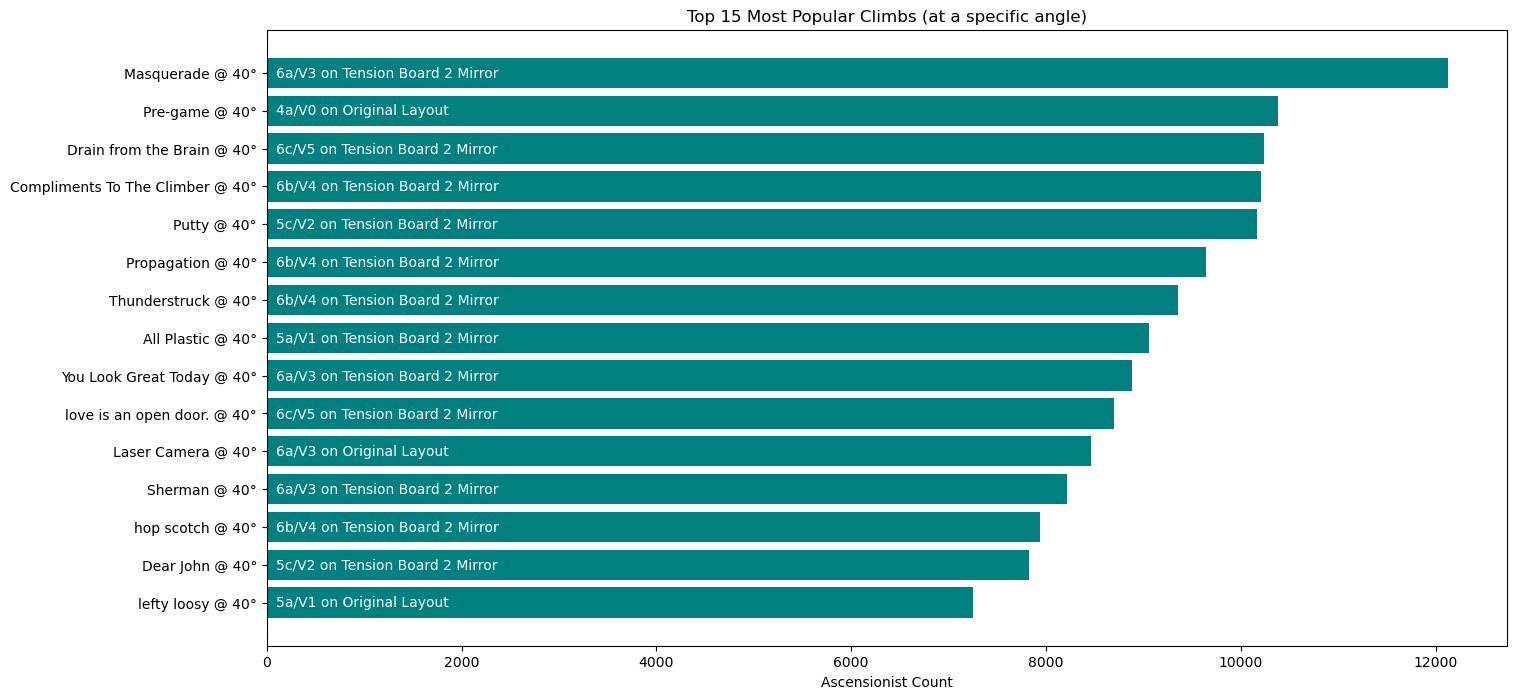

In [16]:
"""
==================================
Most popular climbs
==================================
"""

# The ascensionist_count column will allow us to easily deduce the top 15 climbs. 

# Create a DataFrame with the top 15 climbs
df_popular_climbs = df.sort_values(by='ascensionist_count', ascending=False).head(15)[::-1]

# We want the y-axis to say "Climb @ angle". Let's just create a new column for this. 
df_popular_climbs['y_label'] = df_popular_climbs.apply(
    lambda row: f"{row['climb_name']} @ {row['angle']}°", axis=1
)

# Plot it
fig, ax = plt.subplots(figsize=(16,8))
bars = ax.barh(df_popular_climbs['y_label'], df_popular_climbs['ascensionist_count'], color='teal')
ax.set_xlabel('Ascensionist Count')
ax.set_title('Top 15 Most Popular Climbs (at a specific angle)')

# Add grade and angle labels
for bar, (_, row) in zip(bars, df_popular_climbs.iterrows()):
    label = f"{row['boulder_grade']} on {row['layout_name']}"
    ax.text(100,
            bar.get_y() + bar.get_height()/2,
            label,
            va='center',
            ha='left',
            color='white')


plt.savefig('../images/01_climb_stats/top_15_climbs.png', bbox_inches='tight')
plt.show()


It's unsuprising that every one of these climbs is at 40° given that 40° is the most popular angle, by a long shot.

What about an angle-agnostic analysis? What are the top climbs amonst all angles?

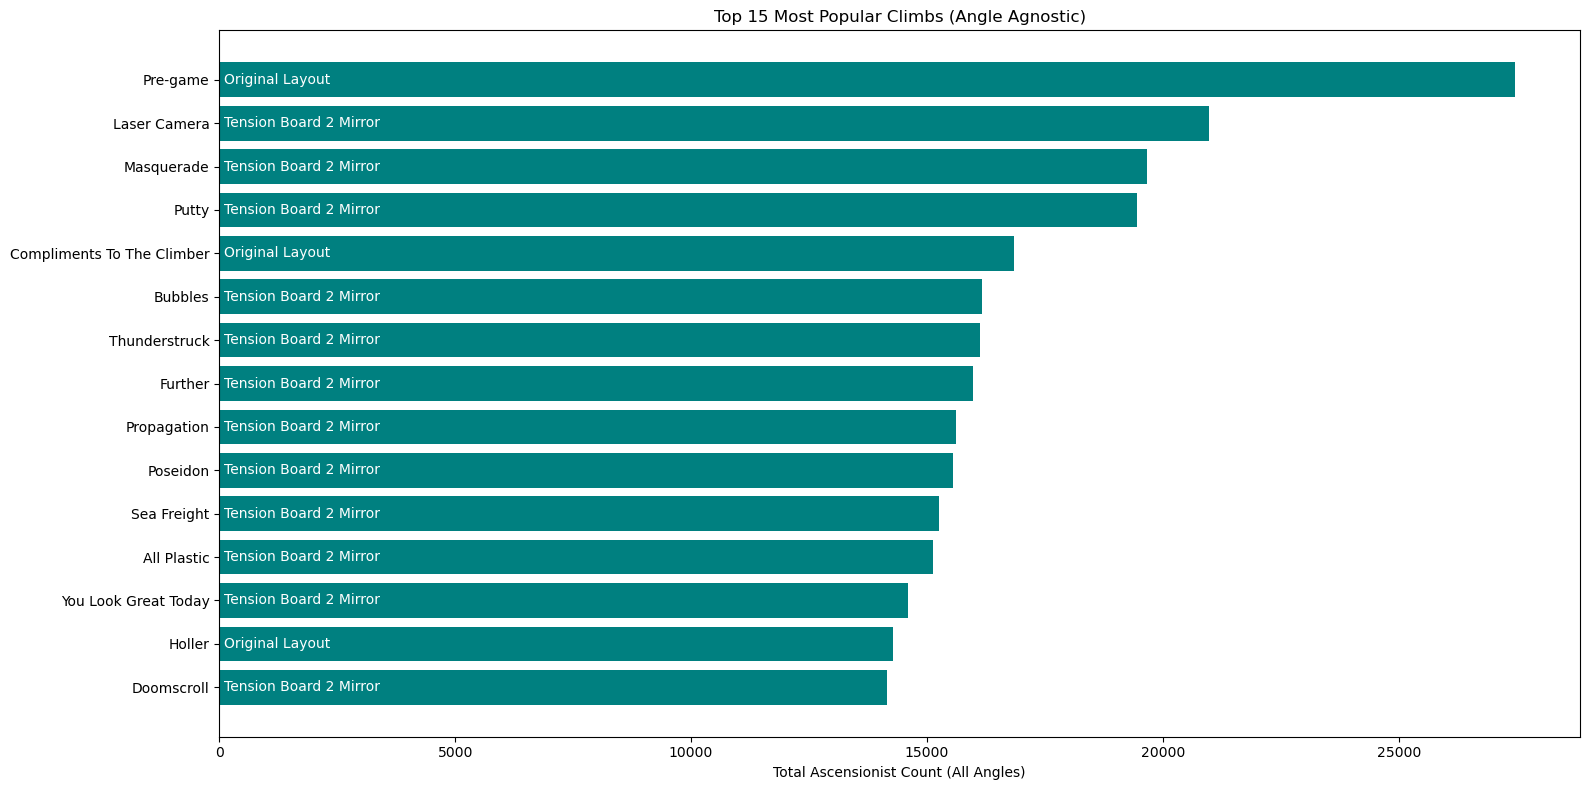

In [17]:
"""
==================================
Top 15 most popular climbs (angle agnostic)
==================================
"""

# Aggregate by climb_name (sum counts across all angles)
df_agg = df.groupby(['climb_name', 'layout_name']).agg(
    total_ascensionists=('ascensionist_count', 'sum'),
    avg_difficulty=('display_difficulty', 'mean')
).reset_index()


# Sort and select top 15
df_popular_climbs_aa = df_agg.sort_values(by='total_ascensionists', ascending=False).head(15)

df_popular_climbs_aa

# Plot
fig, ax = plt.subplots(figsize=(16, 8))
bars = ax.barh(df_popular_climbs_aa['climb_name'], df_popular_climbs_aa['total_ascensionists'], color='teal')
ax.set_xlabel('Total Ascensionist Count (All Angles)')
ax.set_title('Top 15 Most Popular Climbs (Angle Agnostic)')
ax.invert_yaxis()

# Add grade labels inside bars
for bar, (_, row) in zip(bars, df_popular_climbs.iterrows()):
    # Create a label like "(Tension Board 2 Mirror)"
    label = f"{row['layout_name']}" 
    
    ax.text(
        100,  # Position inside bar
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center',
        ha='left',
        color='white'
    )

plt.tight_layout()
plt.savefig('../images/01_climb_stats/top_15_climbs_angle_agnostic.png', bbox_inches='tight')
plt.show()

What about the top climbs (with/without angles) for each of the board layouts? Let's do with angles first. 

In [18]:
"""
==================================
Top 15 most popular climbs by layout
==================================
"""

layouts = df['layout_name'].unique()

for layout in layouts:
    # Filter data for this layout
    df_layout = df[df['layout_name'] == layout]
    
    # Sort by popularity and take top 15
    df_top = df_layout.sort_values(by='ascensionist_count', ascending=False).head(15).reset_index(drop=True)
    
    # Select desired columns
    df_display = df_top[['climb_name', 'angle', 'boulder_grade', 'ascensionist_count']].copy()
    
    # Rename columns for display
    df_display.columns = ['Name', 'Angle', 'Grade', 'Ascensionists']
    
    # Format angle as string with degree symbol
    df_display['Angle'] = df_display['Angle'].astype(int).astype(str) + '°'
    
    # Reset index to show rank 1-15
    df_display.index = df_display.index + 1
    
    print(f"\n{layout}\n")
    display(df_display)


Original Layout



,Name,Angle,Grade,Ascensionists
1,Pre-game,40°,4a/V0,10378
2,Laser Camera,40°,6a/V3,8457
3,lefty loosy,40°,5a/V1,7248
4,Riopio,40°,4a/V0,6961
5,Sea Freight,40°,5c/V2,6953
6,Pre-game,30°,4a/V0,6863
7,Bubbles,40°,6b+/V4,6653
8,Laser Camera,30°,5a/V1,6409
9,Holler,40°,6a/V3,6288
10,Jiggles,40°,6b/V4,5568



Tension Board 2 Mirror



,Name,Angle,Grade,Ascensionists
1,Masquerade,40°,6a/V3,12123
2,Drain from the Brain,40°,6c/V5,10242
3,Compliments To The Climber,40°,6b/V4,10204
4,Putty,40°,5c/V2,10162
5,Propagation,40°,6b/V4,9640
6,Thunderstruck,40°,6b/V4,9352
7,All Plastic,40°,5a/V1,9052
8,You Look Great Today,40°,6a/V3,8881
9,love is an open door.,40°,6c/V5,8693
10,Sherman,40°,6a/V3,8212



Tension Board 2 Spray



,Name,Angle,Grade,Ascensionists
1,Pizza Box,40°,6a/V3,6649
2,"Aw, shoot",40°,6b/V4,5453
3,Write This Way,40°,6a/V3,5145
4,Shoulder Rust,40°,5a/V1,5018
5,Nacho Mango,40°,5c/V2,4841
6,Frictionless,40°,6c/V5,4536
7,Put It Up,40°,6b/V4,4499
8,Pour Cece,40°,6a/V3,4225
9,Authorized,40°,6c/V5,4207
10,It’s A Mid-West Alcohol,40°,6b/V4,4081


On the TB2, it looks like 40 degrees constantly wins out. It is cool to see that, on the TB1, at least one climb made it to the top 15 twice, at two different angles! Congrats "It's Alive."

Now let us do a per-board angle agnostic analysis.

In [19]:
"""
==================================
Top 15 climbs by layout (angle agnostic)
==================================
"""

layouts = df['layout_name'].unique()

# Aggregate counts and collect angles
df_agg = df.groupby(['climb_name', 'layout_name']).agg(
    total_ascensionists=('ascensionist_count', 'sum')
).reset_index()

for layout in layouts:
    df_layout = df_agg[df_agg['layout_name'] == layout]
    df_top = df_layout.sort_values(by='total_ascensionists', ascending=False).head(15).reset_index(drop=True)
    
    df_display = df_top[['climb_name', 'total_ascensionists']].copy()
    df_display.columns = ['Name', 'Total Ascensionists']
    
    # Appropriate index
    df_display.index = df_display.index + 1
    
    print(f"\n### {layout}\n")
    display(df_display)


### Original Layout



,Name,Total Ascensionists
1,Pre-game,27468
2,Laser Camera,20968
3,Bubbles,16161
4,Sea Freight,15264
5,Holler,14275
6,It's Alive!,13545
7,Dull Scissors,11488
8,lefty loosy,11275
9,Getting By,11116
10,Go Figure,10483



### Tension Board 2 Mirror



,Name,Total Ascensionists
1,Masquerade,19655
2,Putty,19445
3,Compliments To The Climber,16844
4,Thunderstruck,16121
5,Further,15981
6,Propagation,15606
7,Poseidon,15549
8,All Plastic,15135
9,You Look Great Today,14607
10,Doomscroll,14150



### Tension Board 2 Spray



,Name,Total Ascensionists
1,Pizza Box,11884
2,Nacho Mango,10325
3,Write This Way,9299
4,Shoulder Rust,8749
5,Marshmallow Dragon,8001
6,Authorized,7387
7,The Where,7325
8,"Aw, shoot",7006
9,Perfect Pizza Party,6575
10,Frictionless,6536


## Prolific setters

Next, we will make a simple table of the most prolific setters by board.

In [20]:
"""
==================================
Top 10 setters by layout
==================================
"""

# Make a DataFrame for the setters
df_setters = df.groupby(['setter_username', 'layout_name']).agg(
    climb_count=('uuid', 'nunique')
).reset_index()

layouts = df['layout_name'].unique()

for layout in layouts:
    df_layout = df_setters[df_setters['layout_name'] == layout]
    df_top = df_layout.sort_values(by='climb_count', ascending=False).head(10).reset_index(drop=True)

    df_display = df_top[['setter_username', 'climb_count']].copy()
    df_display.columns = ['Username', 'Climbs']

    # Reset index to show rank
    df_display.index = df_display.index + 1

    # Display
    print(f"\n{layout}\n")
    display(df_display)
    



Original Layout



,Username,Climbs
1,adamf1234,466
2,jonlackman,383
3,willanglin,332
4,kylejosephharding,328
5,str8_crimpin,247
6,tmon,246
7,gibbs,240
8,topoutclimbinggym,229
9,senderone,227
10,memphisben,198



Tension Board 2 Mirror



,Username,Climbs
1,tensionclimbing,513
2,SocksonBlocs,372
3,limberlimb,353
4,jaketiger111,320
5,mo3_3az,307
6,lijahl,306
7,iansutherland,218
8,theruz,203
9,AlexK,203
10,nicholson.brendan,174



Tension Board 2 Spray



,Username,Climbs
1,MaxClark,246
2,ianmek,217
3,tensionclimbing,175
4,Jeremy_Fullerton,171
5,danielwoodseyetattoo,148
6,Fatbeninco,136
7,rprops,130
8,SPIGGOTT,125
9,milo_forbes,118
10,cotton125,116


---

# Conclusion

At this point we have a board-level and climb-level picture of the dataset. In particular, we now know:

- how large the dataset is,
- how the grade and angle distributions vary across layouts,
- which climbs and setters appear most often,
- and where simple descriptive trends begin to show up.

That gives us enough context to move from *global statistics* to *hold-level structure*. The next notebook focuses on hold usage patterns and board heatmaps, where we stop asking only **how many climbs there are** and start asking **which physical parts of the board are driving those climbs**.